
data loading




In [1]:
import pandas as pd

df = pd.read_csv('steam_games.csv')


df.head()

,Unnamed: 0,name,release_date,discount_final_price,discount_pct,discount_original_price
0,0,Counter-Strike 2,"21 Aug, 2012",Free,NaN,NaN
1,1,S.T.A.L.K.E.R. 2: Heart of Chornobyl,"20 Nov, 2024",249.00 SR,NaN,NaN
2,2,Steam Deck,NaN,NaN,NaN,NaN
3,3,PUBG: BATTLEGROUNDS,"21 Dec, 2017",Free,NaN,NaN
4,4,Call of Duty®: Black Ops 6,"25 Oct, 2024",298.99 SR,NaN,NaN


In [3]:
import pandas as pd
from IPython.display import display

shape_df = pd.DataFrame({"Rows": [df.shape[0]], "Columns": [df.shape[1]]})
display(shape_df.style.set_caption("Dataset Shape").set_table_styles(
    [{'selector': 'th', 'props': [('border', '1px solid black'), ('text-align', 'center')]},
     {'selector': 'td', 'props': [('border', '1px solid black'), ('text-align', 'center')]}]
))

columns_df = pd.DataFrame({"Column Names": df.columns})
display(columns_df.style.set_caption("Column Names").set_table_styles(
    [{'selector': 'th', 'props': [('border', '1px solid black'), ('text-align', 'center')]},
     {'selector': 'td', 'props': [('border', '1px solid black'), ('text-align', 'center')]}]
))

info_data = {
    "Column": df.columns,
    "Non-Null Count": df.notnull().sum(),
    "Data Type": df.dtypes
}
info_df = pd.DataFrame(info_data)
display(info_df.style.set_caption("Columns Info").set_table_styles(
    [{'selector': 'th', 'props': [('border', '1px solid black'), ('text-align', 'center')]},
     {'selector': 'td', 'props': [('border', '1px solid black'), ('text-align', 'center')]}]
))

stats_df = df.describe()
display(stats_df.style.set_caption("Basic Statistics").set_table_styles(
    [{'selector': 'th', 'props': [('border', '1px solid black'), ('text-align', 'center')]},
     {'selector': 'td', 'props': [('border', '1px solid black'), ('text-align', 'center')]}]
))


,Rows,Columns
0,8842,6


,Column Names
0,Unnamed: 0
1,name
2,release_date
3,discount_final_price
4,discount_pct
5,discount_original_price


,Column,Non-Null Count,Data Type
Unnamed: 0,Unnamed: 0,8842,int64
name,name,8842,object
release_date,release_date,8836,object
discount_final_price,discount_final_price,8820,object
discount_pct,discount_pct,1775,object
discount_original_price,discount_original_price,1775,object


,Unnamed: 0
count,8842.000000
mean,4420.500000
std,2552.609874
min,0.000000
25%,2210.250000
50%,4420.500000
75%,6630.750000
max,8841.000000


data cleaning


In [ ]:
# Drop the 'Unnamed: 0' column because it's just an index
df = df.drop(columns=['Unnamed: 0'])
df.head()

,name,release_date,discount_final_price,discount_pct,discount_original_price
0,Counter-Strike 2,"21 Aug, 2012",Free,NaN,NaN
1,S.T.A.L.K.E.R. 2: Heart of Chornobyl,"20 Nov, 2024",249.00 SR,NaN,NaN
2,Steam Deck,NaN,NaN,NaN,NaN
3,PUBG: BATTLEGROUNDS,"21 Dec, 2017",Free,NaN,NaN
4,Call of Duty®: Black Ops 6,"25 Oct, 2024",298.99 SR,NaN,NaN


In [ ]:
# Remove any non-numeric characters (like $, commas, SR) and handle 'Free'
df['discount_final_price'] = df['discount_final_price'].replace('Free', '0', regex=False)
df['discount_final_price'] = df['discount_final_price'].replace('[SR\$,]', '', regex=True).astype(float)

df['discount_original_price'] = df['discount_original_price'].replace('[SR\$,]', '', regex=True).astype(float)

# Remove '%' and convert to float
df['discount_pct'] = df['discount_pct'].replace('%', '', regex=True).astype(float)

<>:3: SyntaxWarning: invalid escape sequence '\$'
<>:5: SyntaxWarning: invalid escape sequence '\$'
<>:3: SyntaxWarning: invalid escape sequence '\$'
<>:5: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipython-input-2533370702.py:3: SyntaxWarning: invalid escape sequence '\$'
  df['discount_final_price'] = df['discount_final_price'].replace('[SR\$,]', '', regex=True).astype(float)
/tmp/ipython-input-2533370702.py:5: SyntaxWarning: invalid escape sequence '\$'
  df['discount_original_price'] = df['discount_original_price'].replace('[SR\$,]', '', regex=True).astype(float)


In [ ]:
# Drop rows where discount_final_price is missing
df = df.dropna(subset=['discount_final_price'])

# (Optional) Fill missing discount_pct with 0
df['discount_pct'] = df['discount_pct'].fillna(0)

In [ ]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
Index: 8820 entries, 0 to 8841
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   name                     8820 non-null   object 
 1   release_date             8815 non-null   object 
 2   discount_final_price     8820 non-null   float64
 3   discount_pct             8820 non-null   float64
 4   discount_original_price  1775 non-null   float64
dtypes: float64(3), object(2)
memory usage: 413.4+ KB
None
       discount_final_price  discount_pct  discount_original_price
count           8820.000000   8820.000000              1775.000000
mean              43.879168     -9.195238                44.084648
std               51.016612     20.833151                42.987553
min                0.000000   -100.000000                 2.750000
25%               15.950000      0.000000                21.950000
50%               30.415000      0.000000                32.

In [ ]:
df.head()

,name,release_date,discount_final_price,discount_pct,discount_original_price
0,Counter-Strike 2,"21 Aug, 2012",0.00,0.0,NaN
1,S.T.A.L.K.E.R. 2: Heart of Chornobyl,"20 Nov, 2024",249.00,0.0,NaN
3,PUBG: BATTLEGROUNDS,"21 Dec, 2017",0.00,0.0,NaN
4,Call of Duty®: Black Ops 6,"25 Oct, 2024",298.99,0.0,NaN
5,Farming Simulator 25,"12 Nov, 2024",142.95,0.0,NaN


In [ ]:
# Fill missing original price with the final price (assume no discount)
df['discount_original_price'] = df['discount_original_price'].fillna(df['discount_final_price'])


print(df.info())
print(df[['discount_final_price', 'discount_original_price', 'discount_pct']].head())

<class 'pandas.core.frame.DataFrame'>
Index: 8820 entries, 0 to 8841
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   name                     8820 non-null   object 
 1   release_date             8815 non-null   object 
 2   discount_final_price     8820 non-null   float64
 3   discount_pct             8820 non-null   float64
 4   discount_original_price  8820 non-null   float64
dtypes: float64(3), object(2)
memory usage: 413.4+ KB
None
   discount_final_price  discount_original_price  discount_pct
0                  0.00                     0.00           0.0
1                249.00                   249.00           0.0
3                  0.00                     0.00           0.0
4                298.99                   298.99           0.0
5                142.95                   142.95           0.0


exploratory data analysis


In [ ]:
df['discount_final_price'].describe()

,discount_final_price
count,8820.000000
mean,43.879168
std,51.016612
min,0.000000
25%,15.950000
50%,30.415000
75%,51.490000
max,1009.990000


In [ ]:
free_games = df[df['discount_final_price'] == 0]
print("Number of free games:", len(free_games))

Number of free games: 505


In [ ]:
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')

print(df['release_date'].dt.year.value_counts().head())

release_date
2024.0    2324
2023.0    1347
2022.0     922
2021.0     751
2020.0     694
Name: count, dtype: int64


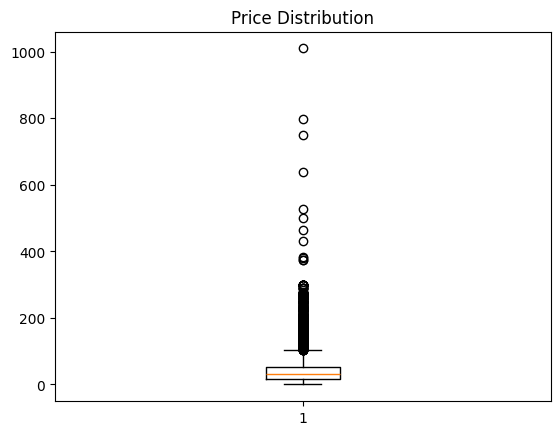

In [ ]:
import matplotlib.pyplot as plt

plt.boxplot(df['discount_final_price'])
plt.title('Price Distribution')
plt.show()

Visualize how final prices are distributed after applying discounts.
The result is that the final game prices start low, and are left in the near zero (0–100) range.

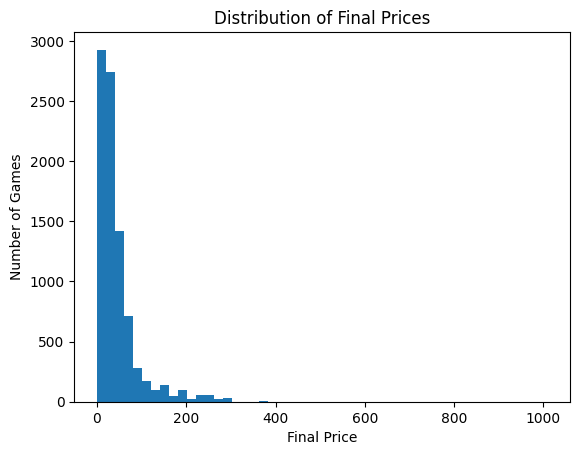

In [ ]:
import matplotlib.pyplot as plt

plt.hist(df['discount_final_price'], bins=50)
plt.title('Distribution of Final Prices')
plt.xlabel('Final Price')
plt.ylabel('Number of Games')
plt.show()

visualize how frequently each discount percentage occurs.
Shows if most games are discounted heavily, lightly, or not at all

Mostly at or close to zero indicates that most of the items are being sold without discount.


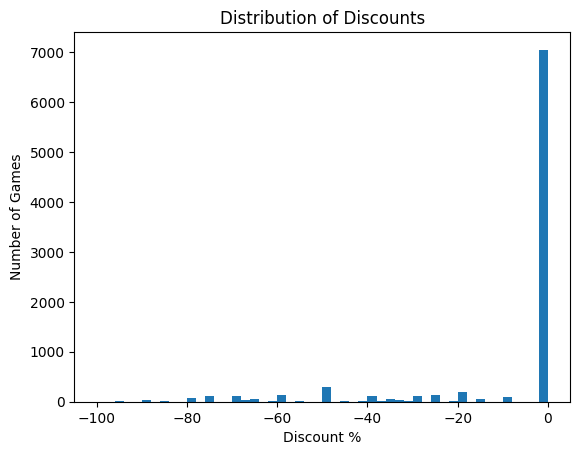

In [ ]:
plt.hist(df['discount_pct'], bins=50)
plt.title('Distribution of Discounts')
plt.xlabel('Discount %')
plt.ylabel('Number of Games')
plt.show()

Visualize relationship between discount percentage and final price.

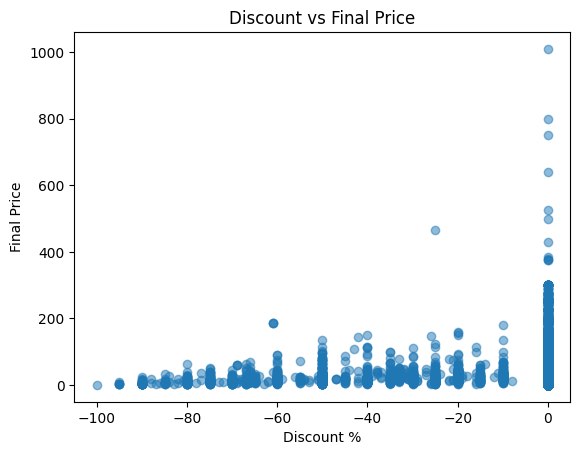

In [ ]:
plt.scatter(df['discount_pct'], df['discount_final_price'], alpha=0.5)
plt.title('Discount vs Final Price')
plt.xlabel('Discount %')
plt.ylabel('Final Price')
plt.show()

In [ ]:
#total number of games
total_games = df.shape[0]
print("Total number of games:", total_games)

#number of games without discount
no_discount_games = df[df['discount_pct'] == 0].shape[0]
print("\nNumber of games without discount:", no_discount_games)

#average final price
average_price = df['discount_final_price'].mean()
print("\nAverage final price:", average_price)

#average discount
average_discount = df['discount_pct'].mean()
print("\nAverage discount percentage:", average_discount)

#Year with most game releases
most_active_year = df['release_date'].dt.year.value_counts().idxmax()
print("\nYear with most game releases:", most_active_year)

#percentage of discount games
discounted_games_ratio = (1 - (no_discount_games / total_games)) * 100
print("\nPercentage of discounted games:", discounted_games_ratio)

#most expensive games
top_10_expensive = df.sort_values(by='discount_final_price', ascending=False).head(10)
print("\nTop 10 most expensive games:")
print(top_10_expensive[['name', 'discount_final_price']])

#cheapest (non-free)
top_10_cheapest = df[df['discount_final_price'] > 0].sort_values(by='discount_final_price').head(10)
print("\nTop 10 cheapest (non-free) games:")
print(top_10_cheapest[['name', 'discount_final_price']])


#Group data by release year and calculate average price
#First, we ensure that the release_date is a real date.

df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')

average_price_by_year = df.groupby(df['release_date'].dt.year)['discount_final_price'].mean()
print("\nAverage price by release year:")
print(average_price_by_year)



Total number of games: 8820

Number of games without discount: 7045

Average final price: 43.87916780045351

Average discount percentage: -9.195238095238095

Year with most game releases: 2024.0

Percentage of discounted games: 20.124716553287982

Top 10 most expensive games:
                                                   name  discount_final_price
2810                                      Houdini Indie               1009.99
5371                         VEGAS Pro 22 Steam Edition                799.00
5818                      Electrical Safety VR Training                749.95
8098                        Karos - Endless performance                640.00
1949        Warframe: Xaku Prime Access - Complete Pack                526.00
653               CyberLink PowerDirector 2024 Ultimate                499.95
5143                    VEGAS Pro Edit 21 Steam Edition                465.00
893                                RealFlight Evolution                431.00
4106  Phantasy Star O

daownload file


In [ ]:
import os
import pandas as pd

output_dir = "cleaned_data"
os.makedirs(output_dir, exist_ok=True)

df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')

total_games = df.shape[0]
print("Total number of games:", total_games)

no_discount_games = df[df['discount_pct'] == 0].shape[0]
print("Number of games without discount:", no_discount_games)

discounted_games_ratio = (1 - (no_discount_games / total_games)) * 100
print("Percentage of discounted games:", discounted_games_ratio)

top_10_expensive = df.sort_values(by='discount_final_price', ascending=False).head(10)
print("\nTop 10 most expensive games:")
print(top_10_expensive[['name', 'discount_final_price']])

top_10_cheapest = df[df['discount_final_price'] > 0].sort_values(by='discount_final_price').head(10)
print("\nTop 10 cheapest (non-free) games:")
print(top_10_cheapest[['name', 'discount_final_price']])

average_price = df['discount_final_price'].mean()
print("\nAverage final price:", average_price)

average_discount = df['discount_pct'].mean()
print("Average discount percentage:", average_discount)

average_price_by_year = df.groupby(df['release_date'].dt.year)['discount_final_price'].mean()
print("\nAverage price by release year:")
print(average_price_by_year)

most_active_year = df['release_date'].dt.year.value_counts().idxmax()
print("\nYear with most game releases:", most_active_year)


# KPIs
kpis = {
    "Total Games": total_games,
    "Games Without Discount": no_discount_games,
    "Discounted Games Percentage": discounted_games_ratio,
    "Average Final Price": average_price,
    "Average Discount Percentage": average_discount,
    "Most Active Release Year": most_active_year
}

kpis_df = pd.DataFrame(list(kpis.items()), columns=["Metric", "Value"])
kpis_df.to_csv(f"{output_dir}/kpis.csv", index=False)

top_10_expensive[['name', 'discount_final_price']].to_csv(
    f"{output_dir}/top_10_expensive.csv", index=False
)

top_10_cheapest[['name', 'discount_final_price']].to_csv(
    f"{output_dir}/top_10_cheapest.csv", index=False
)

average_price_by_year.to_csv(f"{output_dir}/average_price_by_year.csv")

print("✅ All cleaned data and analysis tables have been saved in 'cleaned_data' folder.")

Total number of games: 8820
Number of games without discount: 7045
Percentage of discounted games: 20.124716553287982

Top 10 most expensive games:
                                                   name  discount_final_price
2810                                      Houdini Indie               1009.99
5371                         VEGAS Pro 22 Steam Edition                799.00
5818                      Electrical Safety VR Training                749.95
8098                        Karos - Endless performance                640.00
1949        Warframe: Xaku Prime Access - Complete Pack                526.00
653               CyberLink PowerDirector 2024 Ultimate                499.95
5143                    VEGAS Pro Edit 21 Steam Edition                465.00
893                                RealFlight Evolution                431.00
4106  Phantasy Star Online 2 New Genesis - [SALE] 10...                383.80
87          THRONE AND LIBERTY - Celebration Pack: Gold                3

In [ ]:
import shutil

shutil.make_archive('cleaned_data', 'zip', 'cleaned_data')

from google.colab import files
files.download("cleaned_data.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>